In [85]:
from datetime import datetime

import pandas as pd
import seaborn as sns
from bson import json_util
from rapidfuzz import fuzz
sns.set_theme(style="whitegrid")

In [2]:
def load_mongo_json_with_bson(file_path):
    """Load MongoDB JSON using pymongo's json_util for proper type conversion."""
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()

    return json_util.loads(content)


data = load_mongo_json_with_bson("data/extractions/pl_court_franc_loans_gemini_2.5_flash.json")
df = pd.DataFrame(data)
df = df.join(pd.json_normalize(df["completion_metadata"])).drop(columns=["completion_metadata"])
df = df.join(pd.json_normalize(df["llm_config"])).drop(columns=["llm_config"]).rename(columns={"id": "llm_id"})
df = df.join(pd.json_normalize(df["prompt_config"])).drop(columns=["prompt_config"]).rename(columns={"prompt_id": "prompt_name", "schema_id": "schema_name", "id": "prompt_id"})
df.head()

,_id,created_at,document_id,error,extracted,status,prompt_tokens,completion_tokens,reasoning_tokens,finish_reason,llm_id,llm_name,kwargs.extra_body.thinking.budget_tokens,prompt_id,prompt_name,schema_name
0,f9eeaac20ed8aaa3f0e4bbee394c2b13,2025-09-04 09:06:27.191,155005000001506_III_K_000082_2022_Uz_2023-03-2...,None,"{'sprawa_frankowiczow': 'Nie', 'apelacja': 'nu...",success,17826.0,1571.0,NaN,stop,aaa8f508190820ce399b8fcc948f50cf,gemini-2.5-flash,0,f6d7d7bb8a7eb0e28e7a4c37a1da9eaf,info_extraction_annotated_json_refined_structured,swiss_franc_loans_refined_structured
1,33555af86e712f6f75ef3e6ca8081c65,2025-09-04 09:06:25.035,155020200001506_III_K_000841_2016_Uz_2017-01-1...,None,"{'sprawa_frankowiczow': 'Nie', 'apelacja': 'nu...",success,2768.0,1131.0,NaN,stop,aaa8f508190820ce399b8fcc948f50cf,gemini-2.5-flash,0,f6d7d7bb8a7eb0e28e7a4c37a1da9eaf,info_extraction_annotated_json_refined_structured,swiss_franc_loans_refined_structured
2,359621d32db8cc0feea0d991d82f221b,2025-09-04 09:06:29.226,155020200001506_III_K_000082_2015_Uz_2015-09-1...,None,"{'sprawa_frankowiczow': 'Nie', 'apelacja': 'nu...",success,12688.0,2134.0,NaN,stop,aaa8f508190820ce399b8fcc948f50cf,gemini-2.5-flash,0,f6d7d7bb8a7eb0e28e7a4c37a1da9eaf,info_extraction_annotated_json_refined_structured,swiss_franc_loans_refined_structured
3,2e7853da8c541d82db32b15e19a68506,2025-09-04 09:06:23.231,155020050002527_V_GC_000137_2014_Uz_2014-09-17...,None,"{'sprawa_frankowiczow': 'Nie', 'apelacja': 'Le...",success,6144.0,780.0,NaN,stop,aaa8f508190820ce399b8fcc948f50cf,gemini-2.5-flash,0,f6d7d7bb8a7eb0e28e7a4c37a1da9eaf,info_extraction_annotated_json_refined_structured,swiss_franc_loans_refined_structured
4,49b2c9697ff52ff140f44b2584886d12,2025-09-04 09:06:24.533,155020050001006_II_K_000764_2013_Uz_2014-01-22...,None,"{'sprawa_frankowiczow': 'Nie', 'apelacja': 'nu...",success,969.0,1103.0,NaN,stop,aaa8f508190820ce399b8fcc948f50cf,gemini-2.5-flash,0,f6d7d7bb8a7eb0e28e7a4c37a1da9eaf,info_extraction_annotated_json_refined_structured,swiss_franc_loans_refined_structured


In [5]:
docs = load_mongo_json_with_bson("data/extractions/relevant_docs.json")
docs = pd.DataFrame(docs)
ext_docs = df.set_index("document_id").join(docs.set_index("judgment_id"))
ext_docs = ext_docs[ext_docs["extracted"].apply(lambda x: x["sprawa_frankowiczow"] if x else None) == "Tak"]
ext_docs.head()

,_id,created_at,error,extracted,status,prompt_tokens,completion_tokens,reasoning_tokens,finish_reason,llm_id,...,judgment_type,country,court_type,xml_content,extracted_legal_bases,content,text_legal_bases,dateOfLastUpdate,dateOfPublication,thesis
document_id,,,,,,,,,,,,,,,,,,,,,
154505000008403_XXVIII_C_023019_2022_Uz_2025-07-01_001,c6cf8a8441020a39784b4bded493d4a4,2025-09-04 09:12:37.078,None,"{'sprawa_frankowiczow': 'Tak', 'apelacja': 'Są...",success,11962.0,973.0,NaN,stop,aaa8f508190820ce399b8fcc948f50cf,...,"SENTENCE, REASON",NaN,NaN,NaN,NaN,<?xml version='1.0' encoding='UTF-8'?>\n<xPart...,"[{'text': 'art. 321 § 1 k.p.c.', 'art': 'art. ...",NaN,NaN,NaN
154505000008403_XXVIII_C_001340_2025_Uz_2025-07-23_001,7db5372b5a58f3756768fbdd78310411,2025-09-04 09:12:36.457,None,"{'sprawa_frankowiczow': 'Tak', 'apelacja': 'nu...",success,5988.0,723.0,NaN,stop,aaa8f508190820ce399b8fcc948f50cf,...,"SENTENCE, REASON",NaN,NaN,NaN,NaN,<?xml version='1.0' encoding='UTF-8'?>\n<xPart...,"[{'text': 'art. 180 § 1 pkt 5 lit. b k.p.c.', ...",NaN,NaN,NaN
154505000008403_XXVIII_C_001073_2023_Uz_2025-07-23_001,899d918c730635d7646d6b91910ce6f1,2025-09-04 09:12:36.924,None,"{'sprawa_frankowiczow': 'Tak', 'apelacja': 'Są...",success,6063.0,734.0,NaN,stop,aaa8f508190820ce399b8fcc948f50cf,...,"SENTENCE, REASON",NaN,NaN,NaN,NaN,<?xml version='1.0' encoding='UTF-8'?>\n<xPart...,"[{'text': 'art. 180 § 1 pkt 5 lit. b k.p.c.', ...",NaN,NaN,NaN
154505000008403_XXVIII_C_004103_2024_Uz_2025-07-01_001,29f987c9c5f426d794bf637b91d83eab,2025-09-04 09:12:38.427,None,"{'sprawa_frankowiczow': 'Tak', 'apelacja': 'nu...",success,6196.0,1013.0,NaN,stop,aaa8f508190820ce399b8fcc948f50cf,...,"SENTENCE, REASON",NaN,NaN,NaN,NaN,<?xml version='1.0' encoding='UTF-8'?>\n<xPart...,"[{'text': 'art. 180 § 1 pkt 5 lit. b k.p.c.', ...",NaN,NaN,NaN
153510007020003_XIV_C_000227_2023_Uz_2025-08-25_001,c233ef54c77a10b46581104d44c53e65,2025-09-04 09:12:41.130,None,"{'sprawa_frankowiczow': 'Tak', 'apelacja': 'Są...",success,21401.0,1353.0,NaN,stop,aaa8f508190820ce399b8fcc948f50cf,...,"SENTENCE, REASON",NaN,NaN,NaN,NaN,<?xml version='1.0' encoding='UTF-8'?>\n<xPart...,"[{'text': 'art. 233 § 1 k.p.c.', 'art': 'art. ...",NaN,NaN,NaN


<Axes: xlabel='count', ylabel='judgment_type'>

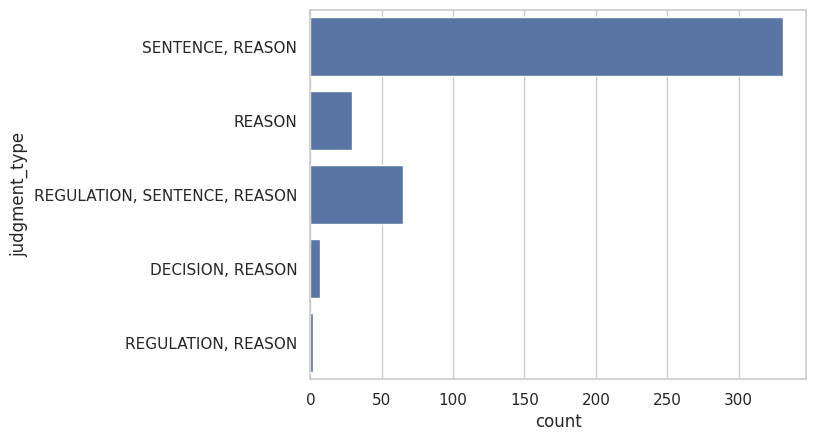

In [6]:
sns.countplot(y=ext_docs["judgment_type"])

[Text(0.5, 1.0, 'Length of full text')]

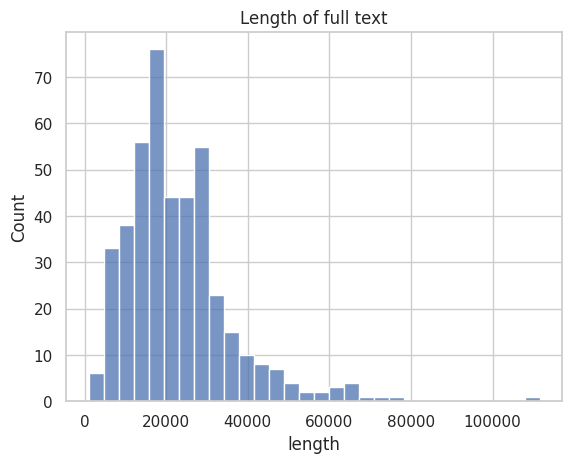

In [7]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")

def tokenize(text: str) -> int:
    tokenized = tokenizer(
        text,
        add_special_tokens=False,
        return_attention_mask=False,
        return_token_type_ids=False,
        return_length=True,
    )
    return tokenized["length"][0]

ext_docs["length"] = ext_docs["full_text"].apply(tokenize)
ext_docs.head()
ax =sns.histplot(ext_docs["length"])
ax.set(title="Length of full text")

# Analyse data

In [8]:
from ydata_profiling import ProfileReport

In [22]:
dfa = df[df["extracted"].apply(lambda x: x["sprawa_frankowiczow"] if x else None) == "Tak"].copy()
print("#sprawa_frankowiczow: ", len(dfa))

dfa = pd.json_normalize(dfa["extracted"]).set_index(dfa.index).join(dfa["document_id"])
dfa["data_wyroku"] = pd.to_datetime(dfa["data_wyroku"].apply(lambda x: x if x != "null" else None))

dfa.sort_values(by="data_wyroku").iloc[-2]["document_id"]

#sprawa_frankowiczow:  434


'152510000001003_II_C_002793_2024_Uz_2025-06-16_001'

In [27]:
with open("data/extractions/franc_ids.txt", "w") as f:
    f.write("\n".join(dfa["document_id"].tolist()))

In [23]:
print(docs.set_index("judgment_id").loc["152510000001003_II_C_002793_2024_Uz_2025-06-16_001", "full_text"])

Sygn. akt II C 2793/24

UZASADNIENIE
W pozwie z dnia 23 grudnia 2024 r. skierowanym przeciwko(...) Bank (...) S.A.wW.powódkaE. M.wniosła o zasądzenie od strony pozwanej na swoją rzecz kwoty 244.153,20 zł., tytułem zwrotu nienależnych świadczeń wykonywanych na rzecz pozwanego w okresie od 26 stycznia 2006 r. do 20 stycznia 2021 r. wraz z ustawowymi odsetkami za opóźnienie liczonymi od kwoty 242.692,13 zł od dnia 6 grudnia 2024 r. do dnia zapłaty i od kwoty 1.461,07 zł. od dnia następnego po dniu doręczenia odpisu pozwu pozwanemu do dnia zapłaty oraz zwrot kosztów postępowania wg norm przepisanych, w tym zastępstwa procesowego w wysokości dwukrotności stawki minimalnej, opłat, zaliczek i opłat skarbowych od pełnomocnictw.
W uzasadnieniu pozwu, podała, iż zawarła z bankiem, którego to następcą prawnym jest pozwany, umowę kredytu mieszkaniowego(...), waloryzowanego kursem franka szwajcarskiego. Zdaniem powódki zaskarżona umowa zawiera szereg klauzul abuzywnych odnoszących się m.in. do walo

In [16]:
profile = ProfileReport(dfa, title="Profiling Report")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 45/45 [00:02<00:00, 18.60it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Compare with pro

In [34]:
res_pro = pd.DataFrame(load_mongo_json_with_bson("data/extractions/pl_court_franc_loans_gemini_2.5_pro_minimal_thinking.json"))
ext_pro = pd.json_normalize(res_pro["extracted"]).set_index(res_pro.index).join(res_pro["document_id"]).set_index("document_id")
ext_pro.head()

,sprawa_frankowiczow,apelacja,data_wyroku,typ_sadu,instancja_sadu,podstawa_prawna_podana,podstawa_prawna,rodzaj_roszczenia,modyfikacje_powodztwa,typ_modyfikacji,...,odsetki_ustawowe,data_rozpoczecia_odsetek,koszty_postepowania,beneficjent_kosztow,zabezpieczenie_udzielone,rodzaj_zabezpieczenia,zabezpieczenie_pierwsza_instancja,czas_trwania_sprawy,wynik_sprawy,szczegoly_wyniku_sprawy
document_id,,,,,,,,,,,,,,,,,,,,,
150515000000503_I_C_000054_2023_Uz_2025-05-06_002,Tak,Nie można ustalić,2025-05-06,Sąd Okręgowy,Sąd I instancji,Tak,"(art. 69 Prawa bankowego), (art. 385(1) k.c.),...",O ustalenie istnienia/nieistnienia stosunku pr...,Nie,Rodzaj roszczenia,...,Tak,Od innej daty,Tak,Powodowie,Nie było wniosku o zabezpieczenie,Nie dotyczy,Nie,28 miesięcy,Wygrana kredytobiorcy,Sąd ustalił nieważność umowy kredytowej i zasą...
150515000000503_I_C_000066_2024_Uz_2025-06-26_002,Tak,białostocka,2025-06-26,Sąd Okręgowy,Sąd I instancji,Tak,"(art. 405 k.c.), (art. 410 k.c.), (art. 481 § ...",O zapłatę,Tak,Rodzaj roszczenia,...,Tak,Od innej daty,Tak,pozwani (powodowie wzajemni),Nie było wniosku o zabezpieczenie,Nie było wniosku o zabezpieczenie,Nie,około 5 miesięcy,Wygrana kredytobiorcy,"Powództwo banku zostało oddalone w całości, na..."
150515000000503_I_C_000070_2023_Uz_2024-12-19_002,Tak,Nie podano,2024-12-19,Sąd Okręgowy,Sąd I instancji,Tak,"(art. 69 prawa bankowego), (art. 353(1) k.c.),...",O ustalenie istnienia/nieistnienia stosunku pr...,Nie,Rodzaj roszczenia,...,Tak,Od innej daty,Tak,Powodowie,Nie było wniosku o zabezpieczenie,null,Nie,23 miesiące,Wygrana kredytobiorcy,Sąd ustalił nieważność umowy kredytowej i zasą...
150515000000503_I_C_000075_2024_Uz_2024-06-27_002,Tak,null,2024-06-27,Sąd Okręgowy,Sąd I instancji,Tak,art. 358(1) § 3 k.c.,O zapłatę,Tak,Kwoty roszczenia,...,Tak,Od innej daty,Tak,"M. N. (1), S. N.",Nie było wniosku o zabezpieczenie,null,Nie,null,Wygrana kredytobiorcy,Postępowanie zostało umorzone z uwagi na cofni...
150515000000503_I_C_000075_2025_Uz_2025-03-14_002,Tak,null,2025-03-14,Sąd Okręgowy,Sąd I instancji,Tak,art. 385(1) k.c.,O ustalenie istnienia/nieistnienia stosunku pr...,Nie,Rodzaj roszczenia,...,Tak,Od innej daty,Tak,powodowie,Nie było wniosku o zabezpieczenie,null,Nie,null,Wygrana kredytobiorcy,Sąd ustalił nieważność umowy kredytu hipoteczn...


In [69]:
ext_flash.astype(str).nunique(axis=0)

sprawa_frankowiczow                    1
apelacja                              38
data_wyroku                          247
typ_sadu                               2
instancja_sadu                         2
podstawa_prawna_podana                 2
podstawa_prawna                      328
rodzaj_roszczenia                      3
modyfikacje_powodztwa                  2
typ_modyfikacji                        2
status_kredytobiorcy                   3
wspoluczestnictwo_powodowe             2
wspoluczestnictwo_pozwanego            2
typ_wspoluczestnictwa                  4
strony_umowy                           2
wczesniejsze_skargi_do_rzecznika       2
umowa_kredytowa                        2
klauzula_niedozwolona                  2
wpisana_do_rejestru_uokik              2
waluta_splaty                          2
aneks_do_umowy                         2
data_aneksu                          187
przedmiot_aneksu                       2
status_splaty_kredytu                  2
rozstrzygniecie_

In [ ]:
ext_flash = dfa.set_index("document_id")
match_ratio = (ext_flash.loc[ext_pro.index] == ext_pro).mean(axis=0).sort_values(ascending=False).rename("match_ratio")
nullity = pd.concat([ext_flash.isna().mean(axis=0).rename("flash_nullity"), ext_pro.isna().mean(axis=0).rename("pro_nullity")], axis=1)
unique_ratio = pd.concat([ext_flash.astype(str).nunique(axis=0).div(ext_flash.shape[0]).rename("flash_unique"), ext_pro.astype(str).nunique(axis=0).div(ext_pro.shape[0]).rename("pro_unique")], axis=1)
nullity.join(unique_ratio).join(match_ratio).sort_values(by="flash_unique", ascending=False)

,flash_nullity,pro_nullity,flash_unique,pro_unique,match_ratio
rozstrzygniecie_sadu,0.000000,0.0,0.986175,0.976959,0.246544
szczegoly_wyniku_sprawy,0.000000,0.0,0.965438,0.981567,0.002304
podstawa_prawna,0.000000,0.0,0.755760,0.728111,0.066820
data_wyroku,0.011521,0.0,0.569124,0.576037,0.983871
data_aneksu,0.000000,0.0,0.430876,0.483871,0.811060
czas_trwania_sprawy,0.000000,0.0,0.317972,0.352535,0.269585
beneficjent_kosztow,0.000000,0.0,0.248848,0.352535,0.315668
apelacja,0.000000,0.0,0.087558,0.078341,0.062212
dowody,0.000000,0.0,0.034562,0.039171,0.661290
rodzaj_zabezpieczenia,0.000000,0.0,0.025346,0.069124,0.790323


151025150000503_I_C_001603_2023_Uz_2025-07-18_001
null
gdańska

154505000008403_XXVIII_C_001340_2025_Uz_2025-07-23_001
null
Warszawska

154505000008403_XXVIII_C_004103_2024_Uz_2025-07-01_001
null
Warszawska

154505000008403_XXVIII_C_000004_2025_Uz_2025-03-03_001
null
Warszawska

150515000000503_I_C_001357_2023_Uz_2025-04-01_002
Białymstok
null

150515000000503_I_C_002291_2024_Uz_2025-04-03_002
Białystok
null

150515000000503_I_C_001693_2024_Uz_2025-02-27_002
null
Warszawska

150515000000503_I_C_000327_2022_Uz_2024-12-19_003
null
warszawska

154505000007503_XXV_C_001334_2020_Uz_2022-11-28_001
null
Warszawska

152510000001003_II_C_002189_2024_Uz_2025-07-16_001
null
Warszawska

154505000008403_XXVIII_C_003536_2024_Uz_2025-04-24_001
null
Warszawska

154505000008403_XXVIII_C_016912_2022_Uz_2025-03-28_001
null
Warszawska

154505000008403_XXVIII_C_023256_2022_Uz_2025-04-24_001
null
Warszawska

154505000008403_XXVIII_C_004047_2024_Uz_2025-05-22_001
null
Warszawska

154505000008403_XXVIII_C_007

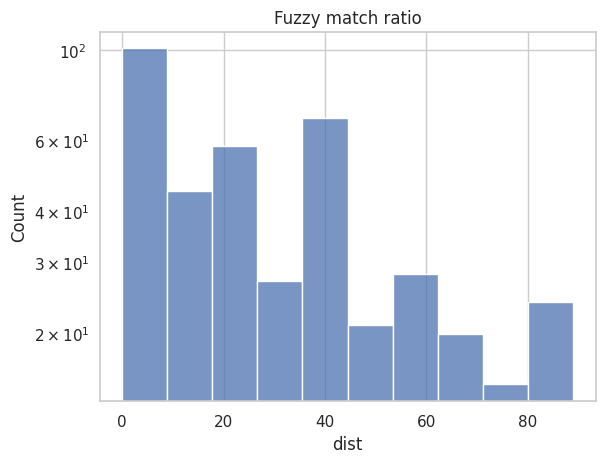

In [101]:
FIELD = "apelacja"
SHOW_EXAMPLES = 20

compare = ext_flash.join(ext_pro, how="inner", lsuffix="_flash", rsuffix="_pro")

cmp = compare[[f"{FIELD}_flash", f"{FIELD}_pro"]]
cmp = cmp[cmp[f"{FIELD}_flash"] != cmp[f"{FIELD}_pro"]]
cmp["dist"] = cmp.apply(lambda x: fuzz.ratio(x[f"{FIELD}_flash"], x[f"{FIELD}_pro"]), axis=1)

ax = sns.histplot(cmp["dist"])
ax.set(yscale="log", title="Fuzzy match ratio")

for i, row in cmp.sort_values(by="dist").head(SHOW_EXAMPLES).iterrows():
    print(i)
    print(row[f"{FIELD}_flash"])
    print(row[f"{FIELD}_pro"])
    print()
